In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.notebook import tqdm

# ==========================================
# 1. 環境設定與資料載入 (🚀 V3 隱形天花板修正版)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"目前使用的運算裝置: {device}")

class DeepSpaceDataset(Dataset):
    def __init__(self, npz_folder):
        self.inputs = []
        self.targets = []
        file_paths = glob.glob(os.path.join(npz_folder, "*.npz"))
        
        print(f"🔍 正在載入 {len(file_paths)} 個 .npz 資料檔...")
        for f in file_paths:
            data = np.load(f)
            self.inputs.append(data['inputs'])
            self.targets.append(data['targets'])
            
        self.inputs = np.concatenate(self.inputs, axis=0)
        self.targets = np.concatenate(self.targets, axis=0)
        self.inputs = np.expand_dims(self.inputs, axis=1)
        self.targets = np.expand_dims(self.targets, axis=1)
        print(f"✅ 資料載入完成！總切片數: {self.inputs.shape[0]}")

    def __len__(self):
        return self.inputs.shape[0]

    def __getitem__(self, idx):
        x = torch.tensor(self.inputs[idx], dtype=torch.float32)
        y = torch.tensor(self.targets[idx], dtype=torch.float32)
        
        # 🌟 V3 核心修正 1：破解隱形天花板！
        # 預處理的範圍是 [-0.05, 1.05] (寬度 1.1, 中點 0.5)
        # 除以 0.55 可以將其完美映射至 [-1.0, 1.0]，保留星星最亮的核心不被切斷！
        x = (x - 0.5) / 0.55
        y = (y - 0.5) / 0.55
        
        x = torch.clamp(x, -1.0, 1.0)
        y = torch.clamp(y, -1.0, 1.0)
        return x, y

DATA_DIR = "processed_dataset"
full_dataset = DeepSpaceDataset(DATA_DIR)

dataset_size = len(full_dataset)
test_size = int(0.2 * dataset_size)
train_size = dataset_size - test_size

train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False, drop_last=False)

print(f"📊 資料集切分: 訓練集 {train_size} 筆, 測試集 {test_size} 筆")

目前使用的運算裝置: cuda
🔍 正在載入 9 個 .npz 資料檔...
✅ 資料載入完成！總切片數: 7133
📊 資料集切分: 訓練集 5707 筆, 測試集 1426 筆


In [2]:
# ==========================================
# 2. 神經網路架構 (完全沿用)
# ==========================================
class UNetDown(nn.Module):
    def __init__(self, in_channels, out_channels, normalize=True, dropout=0.0):
        super().__init__()
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2))
        if dropout > 0.0:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        if dropout > 0.0:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
        
    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)
        return x

class GeneratorUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.down1 = UNetDown(in_channels, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 256)
        self.up3 = UNetUp(512, 128)
        self.up4 = UNetUp(256, 64)
        self.final = nn.Sequential(nn.ConvTranspose2d(128, out_channels, kernel_size=4, stride=2, padding=1), nn.Tanh())
        
    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        u1 = self.up1(d5, d4)
        u2 = self.up2(u1, d3)
        u3 = self.up3(u2, d2)
        u4 = self.up4(u3, d1)
        return self.final(u4)

class Discriminator(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        def discriminator_block(in_filters, out_filters, normalization=True):
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if normalization: layers.append(nn.BatchNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        self.model = nn.Sequential(
            *discriminator_block(in_channels * 2, 64, normalization=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.Conv2d(512, 1, 4, padding=1, bias=False)
        )
        
    def forward(self, img_A, img_B):
        img_input = torch.cat((img_A, img_B), 1)
        return self.model(img_input)

In [3]:
# ==========================================
# 3. 🌟 實例化模型與 PI-cGAN V3 核心物理約束 (線性逆映射版) 🌟
# ==========================================
generator = GeneratorUNet().to(device)
discriminator = Discriminator().to(device)

class PhysicsInformedLossV3(nn.Module):
    def __init__(self, lambda_pixel=100, lambda_fft=0.1, lambda_flux=0.01, asinh_a=0.1): 
        super().__init__()
        self.lambda_pixel = lambda_pixel
        self.lambda_fft = lambda_fft
        self.lambda_flux = lambda_flux
        self.criterion_l1 = nn.L1Loss()
        
        # 準備 Asinh 的逆函數參數
        self.a = asinh_a
        self.arcsinh_1_over_a = np.arcsinh(1.0 / self.a)

    # 🌟 V3 核心修正 2：退回線性物理空間
    def inverse_transform_to_linear(self, tensor_img):
        # 配合 Dataset 的 0.55 修正，逆推回預處理的 [ -0.05, 1.05 ]
        y_original = (tensor_img * 0.55) + 0.5
        y_clamped = torch.clamp(y_original, 0.0, 1.0) # 防止負數雜訊
        # 進行 Inverse Asinh，回到線性疊加的物理空間
        linear_space_img = self.a * torch.sinh(y_clamped * self.arcsinh_1_over_a)
        return linear_space_img

    def forward(self, generated, target):
        # 退回線性物理空間
        gen_linear = self.inverse_transform_to_linear(generated)
        target_linear = self.inverse_transform_to_linear(target)

        # 1. 空間域約束 (改在「線性空間」算 L1，AI 就會專注在極亮星星，拯救 SSIM！)
        loss_pixel = self.criterion_l1(gen_linear, target_linear)

        # 2. 頻率域約束 (維持在 [-1, 1] 視覺空間算，確保背景平滑)
        fft_gen = torch.fft.fft2(generated, norm="ortho")
        fft_target = torch.fft.fft2(target, norm="ortho")
        loss_fft_real = self.criterion_l1(torch.real(fft_gen), torch.real(fft_target))
        loss_fft_imag = self.criterion_l1(torch.imag(fft_gen), torch.imag(fft_target))
        loss_fft = loss_fft_real + loss_fft_imag

        # 3. 物理光通量約束
        star_mask = (target > 0.0).float().detach() 
        # 🌟 核心修正 3：在「線性空間」使用 gen_linear 與 target_linear 進行光子疊加
        flux_gen = torch.sum(gen_linear * star_mask, dim=(2, 3))
        flux_target = torch.sum(target_linear * star_mask, dim=(2, 3))
        loss_flux = self.criterion_l1(flux_gen, flux_target)

        total_pi_loss = (self.lambda_pixel * loss_pixel) + \
                        (self.lambda_fft * loss_fft) + \
                        (self.lambda_flux * loss_flux)

        return total_pi_loss, loss_pixel, loss_fft, loss_flux

pi_criterion = PhysicsInformedLossV3(lambda_pixel=100, lambda_fft=0.1, lambda_flux=0.01).to(device)
criterion_pixelwise = nn.L1Loss().to(device)
criterion_GAN = nn.BCEWithLogitsLoss().to(device)

OUTPUT_PICGAN_DIR = "PI_cGAN_V3_Ultimate_results"
os.makedirs(OUTPUT_PICGAN_DIR, exist_ok=True)
print(f"📁 已建立 V3 專屬存檔資料夾：{OUTPUT_PICGAN_DIR}")

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
epochs = 200

📁 已建立 V3 專屬存檔資料夾：PI_cGAN_V3_Ultimate_results


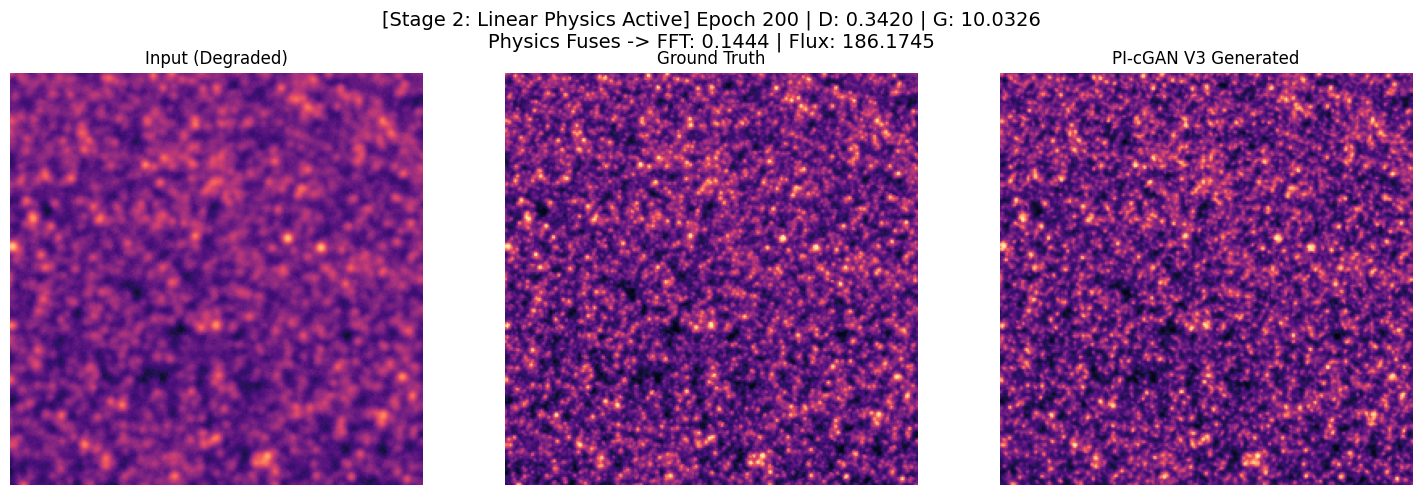

💾 Epoch 200 測試數據已安全儲存至 PI_cGAN_V3_Ultimate_results。

🎉 PI-cGAN V3 訓練完成！


In [4]:
# ==========================================
# 4. 訓練監控與 V3 課程學習訓練迴圈
# ==========================================
def show_current_results(test_A, test_B, fake_B, epoch, d_loss, g_loss, fft_loss, flux_loss, stage_name):
    img_A = test_A[0, 0].cpu().detach().numpy()
    img_B = test_B[0, 0].cpu().detach().numpy()
    img_fake = fake_B[0, 0].cpu().detach().numpy()
    
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"[{stage_name}] Epoch {epoch+1} | D: {d_loss:.4f} | G: {g_loss:.4f}\nPhysics Fuses -> FFT: {fft_loss:.4f} | Flux: {flux_loss:.4f}", fontsize=14)
    
    axes[0].imshow(img_A, cmap='magma', origin='lower', vmin=-1, vmax=1)
    axes[0].set_title("Input (Degraded)")
    axes[0].axis('off')
    
    axes[1].imshow(img_B, cmap='magma', origin='lower', vmin=-1, vmax=1)
    axes[1].set_title("Ground Truth")
    axes[1].axis('off')
    
    axes[2].imshow(img_fake, cmap='magma', origin='lower', vmin=-1, vmax=1)
    axes[2].set_title("PI-cGAN V3 Generated")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

print("🚀 開始訓練 PI-cGAN V3 模型 (隱形天花板突破 + 逆映射物理約束)...")
warmup_epochs = 100 

for epoch in tqdm(range(epochs), desc="PI-cGAN V3 Training Progress"):
    generator.train()
    discriminator.train()
    
    epoch_loss_fft = 0.0
    epoch_loss_flux = 0.0
    
    for i, (real_A, real_B) in enumerate(train_dataloader):
        real_A, real_B = real_A.to(device), real_B.to(device)

        # ------------------ Generator ------------------
        optimizer_G.zero_grad()
        fake_B = generator(real_A)
        
        pred_fake = discriminator(real_A, fake_B)
        valid = torch.ones_like(pred_fake, device=device, requires_grad=False)
        loss_GAN = criterion_GAN(pred_fake, valid)
        
        if epoch < warmup_epochs:
            # Stage 1: 熱身期，讓 CNN 先學會在視覺空間把圖畫得像
            loss_pixel = criterion_pixelwise(fake_B, real_B)
            loss_G = loss_GAN + (100 * loss_pixel)
            loss_fft_val, loss_flux_val = 0.0, 0.0
        else:
            # Stage 2: 啟動 V3 終極物理引擎 (線性空間 L1 + GT 遮罩光通量)
            total_pi_loss, loss_pixel, loss_fft, loss_flux = pi_criterion(fake_B, real_B)
            loss_G = loss_GAN + total_pi_loss
            loss_fft_val = loss_fft.item()
            loss_flux_val = loss_flux.item()
        
        loss_G.backward()
        optimizer_G.step()
        
        epoch_loss_fft += loss_fft_val
        epoch_loss_flux += loss_flux_val

        # ------------------ Discriminator ------------------
        optimizer_D.zero_grad()
        pred_real = discriminator(real_A, real_B)
        loss_real = criterion_GAN(pred_real, torch.ones_like(pred_real))
        pred_fake_detach = discriminator(real_A, fake_B.detach())
        loss_fake = criterion_GAN(pred_fake_detach, torch.zeros_like(pred_fake_detach))
        loss_D = 0.5 * (loss_real + loss_fake)
        loss_D.backward()
        optimizer_D.step()

    # --- 推論與存檔 ---
    generator.eval()
    with torch.no_grad():
        test_A, test_B = next(iter(test_dataloader))
        test_A, test_B = test_A.to(device), test_B.to(device)
        test_fake_B = generator(test_A)
        
        avg_fft_loss = epoch_loss_fft / len(train_dataloader)
        avg_flux_loss = epoch_loss_flux / len(train_dataloader)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            stage_name = "Stage 1: Warmup (Visual L1)" if epoch < warmup_epochs else "Stage 2: Linear Physics Active"
            show_current_results(test_A, test_B, test_fake_B, epoch, loss_D.item(), loss_G.item(), avg_fft_loss, avg_flux_loss, stage_name)
        
        if (epoch + 1) % 40 == 0:
            save_path_npz = os.path.join(OUTPUT_PICGAN_DIR, f"picgan_ep{epoch+1}_test_data.npz")
            np.savez_compressed(save_path_npz, inputs=test_A.cpu().numpy(), targets=test_B.cpu().numpy(), generated=test_fake_B.cpu().numpy())
            save_path_pth = os.path.join(OUTPUT_PICGAN_DIR, f"picgan_ep{epoch+1}_weights.pth")
            torch.save(generator.state_dict(), save_path_pth)
            print(f"💾 Epoch {epoch+1} 測試數據已安全儲存至 {OUTPUT_PICGAN_DIR}。")

print("\n🎉 PI-cGAN V3 訓練完成！")

📊 總共載入 16 張 PI-cGAN V3 測試圖片進行分析...
⚙️ 正在計算 V3 空間域指標與頻域 RAPS 特徵...


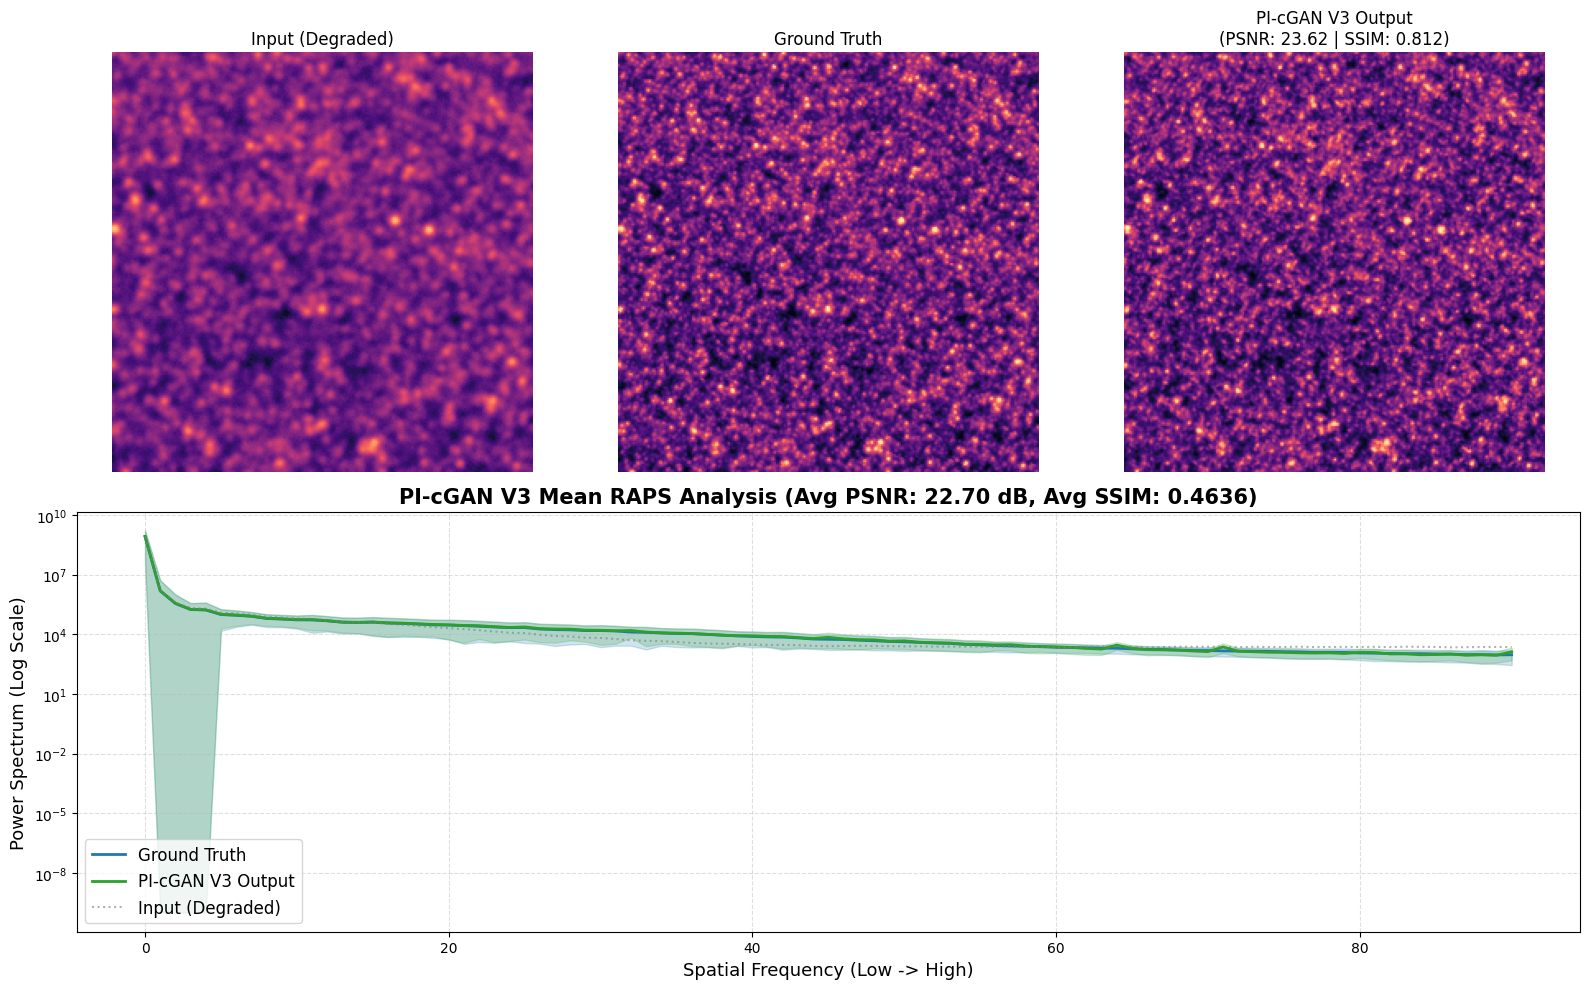

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# 1. 🌟 改為讀取 V3 專屬資料夾
file_path = "PI_cGAN_V3_Ultimate_results/picgan_ep120_test_data.npz"
data = np.load(file_path)

inputs = data['inputs']
targets = data['targets']
generated = data['generated']

num_images, _, h, w = inputs.shape
print(f"📊 總共載入 {num_images} 張 PI-cGAN V3 測試圖片進行分析...")

# ==========================================
# 預先計算半徑矩陣
# ==========================================
center = (int(h/2), int(w/2))
y, x = np.indices((h, w))
r_matrix = np.sqrt((x - center[1])**2 + (y - center[0])**2).astype(int)
nr = np.bincount(r_matrix.ravel())

# ==========================================
# 計算單張 RAPS
# ==========================================
def calculate_raps_fast(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    power_spectrum = np.abs(f_shift)**2
    tbin = np.bincount(r_matrix.ravel(), power_spectrum.ravel())
    radialprofile = tbin / nr
    return radialprofile

# ==========================================
# 2. 計算 RAPS 與 圖像指標
# ==========================================
all_raps_in, all_raps_gt, all_raps_gen = [], [], []
psnr_gen_list, ssim_gen_list = [], []

print("⚙️ 正在計算 V3 空間域指標與頻域 RAPS 特徵...")
for i in range(num_images):
    img_in = inputs[i, 0]
    img_gt = targets[i, 0]
    img_gen = generated[i, 0]
    
    all_raps_in.append(calculate_raps_fast(img_in))
    all_raps_gt.append(calculate_raps_fast(img_gt))
    all_raps_gen.append(calculate_raps_fast(img_gen))
    
    psnr_val = psnr(img_gt, img_gen, data_range=2.0)
    ssim_val = ssim(img_gt, img_gen, data_range=2.0)
    psnr_gen_list.append(psnr_val)
    ssim_gen_list.append(ssim_val)

mean_raps_in = np.mean(all_raps_in, axis=0)
mean_raps_gt = np.mean(all_raps_gt, axis=0)
mean_raps_gen = np.mean(all_raps_gen, axis=0)

std_raps_gt = np.std(all_raps_gt, axis=0)
std_raps_gen = np.std(all_raps_gen, axis=0)

freq_len = len(mean_raps_gt) // 2
x_freq = np.arange(freq_len)

mean_psnr = np.mean(psnr_gen_list)
mean_ssim = np.mean(ssim_gen_list)

# ==========================================
# 繪圖視覺化
# ==========================================
fig = plt.figure(figsize=(16, 10))

display_idx = 0 
ax1 = plt.subplot(2, 3, 1)
ax1.imshow(inputs[display_idx, 0], cmap='magma', origin='lower', vmin=-1, vmax=1)
ax1.set_title(f"Input (Degraded)")
ax1.axis('off')

ax2 = plt.subplot(2, 3, 2)
ax2.imshow(targets[display_idx, 0], cmap='magma', origin='lower', vmin=-1, vmax=1)
ax2.set_title(f"Ground Truth")
ax2.axis('off')

ax3 = plt.subplot(2, 3, 3)
ax3.imshow(generated[display_idx, 0], cmap='magma', origin='lower', vmin=-1, vmax=1)
ax3.set_title(f"PI-cGAN V3 Output\n(PSNR: {psnr_gen_list[display_idx]:.2f} | SSIM: {ssim_gen_list[display_idx]:.3f})")
ax3.axis('off')

ax4 = plt.subplot(2, 1, 2)
ax4.plot(x_freq, mean_raps_gt[:freq_len], label='Ground Truth', linewidth=2, color='#1f77b4')
ax4.fill_between(x_freq, 
                 np.maximum(mean_raps_gt[:freq_len] - std_raps_gt[:freq_len], 1e-10), 
                 mean_raps_gt[:freq_len] + std_raps_gt[:freq_len], 
                 color='#1f77b4', alpha=0.2)

ax4.plot(x_freq, mean_raps_gen[:freq_len], label='PI-cGAN V3 Output', linewidth=2, color='#2ca02c')
ax4.fill_between(x_freq, 
                 np.maximum(mean_raps_gen[:freq_len] - std_raps_gen[:freq_len], 1e-10), 
                 mean_raps_gen[:freq_len] + std_raps_gen[:freq_len], 
                 color='#2ca02c', alpha=0.2)

ax4.plot(x_freq, mean_raps_in[:freq_len], label='Input (Degraded)', alpha=0.6, linestyle=':', color='gray')

ax4.set_yscale('log')
ax4.set_title(f"PI-cGAN V3 Mean RAPS Analysis (Avg PSNR: {mean_psnr:.2f} dB, Avg SSIM: {mean_ssim:.4f})", fontsize=15, fontweight='bold')
ax4.set_xlabel("Spatial Frequency (Low -> High)", fontsize=13)
ax4.set_ylabel("Power Spectrum (Log Scale)", fontsize=13)
ax4.legend(fontsize=12, loc='lower left')
ax4.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()

⚙️ 正在計算 V3 傅立葉相位誤差與【線性物理空間】光通量守恆...


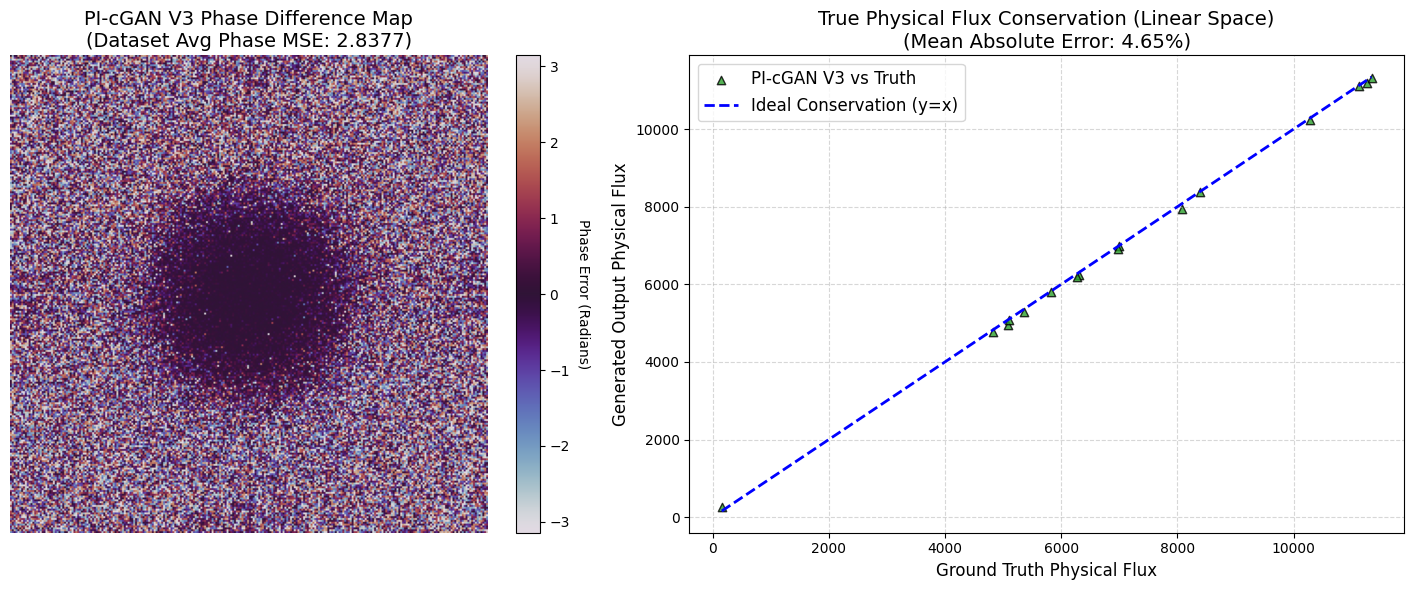

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 🌟 讀取 V3 數據
file_path = "PI_cGAN_V3_Ultimate_results/picgan_ep120_test_data.npz"
data = np.load(file_path)

inputs = data['inputs']
targets = data['targets']
generated = data['generated']
num_images = inputs.shape[0]

print("⚙️ 正在計算 V3 傅立葉相位誤差與【線性物理空間】光通量守恆...")

def calculate_phase(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    return np.angle(f_shift)

# 計算 Phase MSE
phase_mse_list = []
for i in range(num_images):
    phase_gt = calculate_phase(targets[i, 0])
    phase_gen = calculate_phase(generated[i, 0])
    phase_diff = np.angle(np.exp(1j * (phase_gt - phase_gen)))
    phase_mse = np.mean(phase_diff**2)
    phase_mse_list.append(phase_mse)

mean_phase_mse = np.mean(phase_mse_list)

# ==========================================
# 🌟 V3 核心修正：對齊 V3 模型中的逆轉換公式 (0.55)
# ==========================================
flux_gt_list = []
flux_gen_list = []

a = 0.1
arcsinh_1_over_a = np.arcsinh(1.0 / a)

for i in range(num_images):
    img_gt = targets[i, 0]
    img_gen = generated[i, 0]
    
    # 🌟 使用 V3 的映射比例退回 [0, 1] 並加上 Clamp 避免極端值
    gt_01 = np.clip((img_gt * 0.55) + 0.5, 0.0, 1.0)
    gen_01 = np.clip((img_gen * 0.55) + 0.5, 0.0, 1.0)
    
    # 逆推回真實線性物理空間 (Linear Physical Space)
    gt_linear = a * np.sinh(gt_01 * arcsinh_1_over_a)
    gen_linear = a * np.sinh(gen_01 * arcsinh_1_over_a)
    
    # 在線性空間用嚴格的 1e-4 當作遮罩 (過濾純背景)
    star_mask = gt_linear > 1e-4
    
    flux_gt = np.sum(gt_linear[star_mask])
    flux_gen = np.sum(gen_linear[star_mask])
    
    if flux_gt > 1e-5:
        flux_gt_list.append(flux_gt)
        flux_gen_list.append(flux_gen)

flux_gt_arr = np.array(flux_gt_list)
flux_gen_arr = np.array(flux_gen_list)

# 計算線性物理空間的真實誤差
flux_mape = np.mean(np.abs(flux_gt_arr - flux_gen_arr) / flux_gt_arr) * 100

# 開始繪圖
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

display_idx = 0
phase_gt_sample = calculate_phase(targets[display_idx, 0])
phase_gen_sample = calculate_phase(generated[display_idx, 0])
phase_diff_sample = np.angle(np.exp(1j * (phase_gt_sample - phase_gen_sample)))

im1 = axes[0].imshow(phase_diff_sample, cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[0].set_title(f"PI-cGAN V3 Phase Difference Map\n(Dataset Avg Phase MSE: {mean_phase_mse:.4f})", fontsize=14)
axes[0].axis('off')
cbar = fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar.set_label('Phase Error (Radians)', rotation=270, labelpad=15)

# 右圖散佈圖
axes[1].scatter(flux_gt_arr, flux_gen_arr, alpha=0.8, color='#2ca02c', marker='^', edgecolors='k', label='PI-cGAN V3 vs Truth')

max_flux = max(np.max(flux_gt_arr), np.max(flux_gen_arr))
min_flux = min(np.min(flux_gt_arr), np.min(flux_gen_arr))
axes[1].plot([min_flux, max_flux], [min_flux, max_flux], 'b--', linewidth=2, label='Ideal Conservation (y=x)')

axes[1].set_title(f"True Physical Flux Conservation (Linear Space)\n(Mean Absolute Error: {flux_mape:.2f}%)", fontsize=14)
axes[1].set_xlabel("Ground Truth Physical Flux", fontsize=12)
axes[1].set_ylabel("Generated Output Physical Flux", fontsize=12)
axes[1].legend(fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from IPython.display import display

# 🌟 讀取 V3 數據
file_path = "PI_cGAN_V3_Ultimate_results/picgan_ep120_test_data.npz"
data = np.load(file_path)

inputs = data['inputs']
targets = data['targets']
generated = data['generated']
num_images = inputs.shape[0]

print(f"📦 成功載入 {num_images} 張圖片，準備產出 V3 最終數據報表...")

all_metrics = []
a = 0.1
arcsinh_1_over_a = np.arcsinh(1.0 / a)

for i in range(num_images):
    img_in = inputs[i, 0]
    img_gt = targets[i, 0]
    img_gen = generated[i, 0]
    
    psnr_val = psnr(img_gt, img_gen, data_range=2.0)
    ssim_val = ssim(img_gt, img_gen, data_range=2.0)
    
    phase_gt = np.angle(np.fft.fftshift(np.fft.fft2(img_gt)))
    phase_gen = np.angle(np.fft.fftshift(np.fft.fft2(img_gen)))
    phase_diff = np.angle(np.exp(1j * (phase_gt - phase_gen)))
    phase_mse = np.mean(phase_diff**2)
    
    # 🌟 V3 核心修正：對齊 V3 模型中的逆轉換公式 (0.55)
    gt_01 = np.clip((img_gt * 0.55) + 0.5, 0.0, 1.0)
    gen_01 = np.clip((img_gen * 0.55) + 0.5, 0.0, 1.0)
    
    gt_linear = a * np.sinh(gt_01 * arcsinh_1_over_a)
    gen_linear = a * np.sinh(gen_01 * arcsinh_1_over_a)
    
    star_mask = gt_linear > 1e-4
    
    flux_gt = np.sum(gt_linear[star_mask])
    flux_gen = np.sum(gen_linear[star_mask])
    
    if flux_gt > 1e-5:
        flux_error_percent = np.abs(flux_gt - flux_gen) / flux_gt * 100
    else:
        flux_error_percent = np.nan 
        
    all_metrics.append({
        "Image_ID": f"Test_Sample_{i:02d}",
        "PSNR (dB)": round(psnr_val, 4),
        "SSIM": round(ssim_val, 4),
        "Phase_MSE (rad)": round(phase_mse, 4),
        "GT_Linear_Flux": round(flux_gt, 2),
        "Gen_Linear_Flux": round(flux_gen, 2),
        "Linear_Flux_Error (%)": round(flux_error_percent, 2)
    })

df_metrics = pd.DataFrame(all_metrics)

mean_values = df_metrics.mean(numeric_only=True).round(4)
mean_row = pd.DataFrame([mean_values])
mean_row.insert(0, "Image_ID", "PI-cGAN_V3_AVERAGE")

df_final = pd.concat([df_metrics, mean_row], ignore_index=True)

# 🌟 存檔至 V3 資料夾
output_csv_path = "PI_cGAN_V3_Ultimate_results/picgan_v3_metrics_report.csv"
df_final.to_csv(output_csv_path, index=False, encoding='utf-8-sig')

print(f"✅ V3 報表萃取完成！已成功匯出至：{output_csv_path}")
display(df_final.tail())

📦 成功載入 16 張圖片，準備產出 V3 最終數據報表...
✅ V3 報表萃取完成！已成功匯出至：PI_cGAN_V3_Ultimate_results/picgan_v3_metrics_report.csv


,Image_ID,PSNR (dB),SSIM,Phase_MSE (rad),GT_Linear_Flux,Gen_Linear_Flux,Linear_Flux_Error (%)
12,Test_Sample_12,18.4598,0.1522,3.0858,11269.9900,11179.8900,0.8000
13,Test_Sample_13,32.6992,0.8424,2.7820,158.8800,256.9700,61.7400
14,Test_Sample_14,18.1559,0.0990,3.1646,11340.8400,11310.4400,0.2700
15,Test_Sample_15,24.8764,0.8100,2.3894,5105.3400,5076.3900,0.5700
16,PI-cGAN_V3_AVERAGE,22.6964,0.4636,2.8377,7087.3662,7041.9562,4.6544
